<a href="https://colab.research.google.com/github/Alien-73/Building_Energy_Flex/blob/main/build_RC_MPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Building Simulation**
This code simulates a building behaviour. Right now it has below features:

Objective: Single -> to Minimize the cost/energy consumption

Thermal comfort: Based on indoor temperature -> Hard constraints on indoor temperature (20,24)

# **0. Building model**
based on a 3R2C model: The parameters are:

Rie, Rea, Rinf, Ci, Ce, Ai, Ae

*Ref:*

*A. Peder and Madsen 2011*

*B. Yu, Xingji, et al. "Influence of data pre-processing and sensor dynamics on grey-box models for space-heating: Analysis using field measurements." Building and Environment 212 (2022): 108832.  *

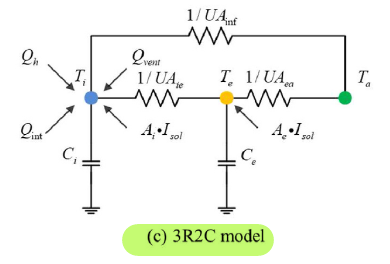

In [2]:
pip install casadi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 13.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
from scipy.linalg import expm
import casadi
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import clear_output

clear_output()

In [4]:
nx = 2 #The number of states
nu = 1 #The number of controls
#-----------------------------------------

#Cost function weights (?)
Q = casadi.diag([1.0,0]) #The weights as in Q[0]*(x[0]-x_ref) + Q[1]*(x[1]-x_ref) + ...
R = casadi.diag([1.0])  #The weights as in R[0]*(u[0]-u_ref) + R[1]*(u[1]-u_ref) + ...
Q_f = casadi.diag([1,1]) #?

#constraints
x_lb = [20,-np.inf] #Additon: I can delete these to make the soft constraint on temp.
x_ub = [24,np.inf]
u_lb = [0]#,0
u_ub = [6]#,5

#traget values
x_ref = casadi.DM([22,0]) #ADDITION: I only put reference on x_0 (T_in). and T_e we dont care. Change for temp. 21deg.C for example
u_ref = casadi.DM([0]) #ADDITION: Keep 0 because we rather not use heat pump to save vost


In [11]:
#Inputs
#----------------------------------------------
#Building Model:

#Type: Residential
#Building model type: 3R2C (Ref: DTU summer course) -> Rie, Rea, Rinf, Ci, Ce
#Parameters
Rea = 58.4895  #['C/kW]
Rie = 1.1521  #['C/kW]
Rinf = 15.748 #['C/kW]
Ce = 3.5     #[kWh/'C]
Ci = 1.15     #[kWh/'C]
Ai = 1.56     #[m^2]
Ae = 0.122    #[m^2]
#----------------------------------------------
#Weather and and External datasets
# reading csv file
df = pd.read_csv("data.csv")
#print(df.head())

#Qint = df["Qint"]#"Qint":internal process heating [kW]
#Qvent = df["Qvent"]#"Qvent":the ventilation heating loss [kW]
Gh = df["Gv"] #"Gh" horizental solar radiation [kW/m.sq]
Ta = df["Ta"] #"Ta" ourdoor temp. [de.C]
#This is unknown #"Q_h":heating input [kW]

# Define T_o_seri and Q_sol_seri from the loaded data
T_o_seri = Ta
Q_sol_seri = Gh

#Weather noise

p11 = -2.89726 #Sample FROM DTU case - Summer course Friday session
p22 = -0.06793 #Sample FROM DTU case - Summer course Friday session
#Noise
Noise_level = 1
#generated based on Brownian Motion Noise
np.random.seed(seed=45)
#noise_Ti = np.cumsum(np.random.normal(0,sd_Ti , t_eval.size)) #sd_Ti*np.sqrt(dt)
#noise_Th = np.cumsum(np.random.normal(0, sd_Th*np.sqrt(dt), t_eval.size))
#noise_Te = np.cumsum(np.random.normal(0,sd_Tm , t_eval.size)) #sd_Te*np.sqrt(dt)
#noise_Ti = Noise_level* np.diff(noise_Ti,axis=0)
#noise_Te = Noise_level* np.diff(noise_Te,axis=0)
#OR pre calculated noise fro CSV
df2 = pd.read_csv('noise.csv')
noise_Ti = df2["Bin"]* Noise_level
noise_Te = df2["Bm"]* Noise_level


#----------------------------------------
#Simulation Inputs:
t_sim = 75 #Total Simulation horizon [hr]
T = 6     #Control Horizon [hr] -> Number of hr to predict (in my case 6 x 10-min steps which is 1hr)
K = 24    #Control Horizon [Steps]
dt = T/K  #Sampling time [hr] (for me 15 mins)

Steps_sim = t_sim/dt+1 #Number of steps [-]
#Generating timeline
t_eval = np.arange(0,t_sim+T,dt)
total = nx*(K+1) + nu*K #Dimentions of optimization variables
#----------------------------------------
#Prices
#Fixed price:
el_price = int(Steps_sim) * [0.909]
#X = [Ti Te]*T
#U = [Q_h Qvent Qint Ta Gh]*T  #"Qint" "Qvent" "Gh" "Ta" are known
#OR FROM CSV
#df3 = pd.read_csv('price.csv')
#-------------------------------------
#Heating System
Eff_h = 0.95 #Eff. of the  heating in the building - ATT: should be changed if HP is being used

x_init = casadi.DM([23.5,23.5]) #initial values
x0 = casadi.DM.zeros(total)

In [12]:
#Functions & preprocessing

#Building
#Ordinary Diff. Equation in the following form
#___________________________________________________________________
#dTi/dt = (1/(Ci*Rie)*(Te-Ti) + 1/(Ci*Rinf)*(Ta-Ti) + 1/Ci*(Qh + Qint(x) + Qvent(Already known, I am gonna use them!) + Qdh + Ai*Gh))*dt + dw11*dt
#dTe/dt = (1/(Ce*Rie)*(Ti-Te) + 1/(Ce*Rea)*(Ta-Te) + 1/Ce*(Ae*Gh)*dt + exp(p22)/Cm*dw22)
#___________________________________________________________________

import numpy as np
from scipy.linalg import expm
#Descretsizing the continuous state-space model:
#dx/dt  = A*x + B*u
#y      = C*x + D*u
#to:
#x(k+1) = Ad*x + Bd*u
#y(k)   = C*x + D*u

def discretize(A, B, dT): #A and B as above and T is the timestep (0.25hr)
    # Compute A_d
    A_d = expm(A * dT)

    # Compute B_d using the formula B_d = A_inv * (A_d - I) * B
    # if A is invertible
    n = A.shape[0]
    B_d = np.linalg.inv(A) @ (A_d - np.eye(n)) @ B

    return A_d, B_d

def AB_matrices(Rea, Rie, Rinf, Ci, Ce,Ai,Ae, eta): #System model
    """
    Build continuous-time A (2x2) and B (2x2) matrices for the 3R2C thermal model:
      [Ti_dot, Te_dot]^T = A [Ti, Te]^T + B [Qh, Qinit, Qvent,T_out, Q_sol]^T
    """
    # Safety valve --> divide-by-zero; small floor
    eps = 1e-9
    Rea  = max(Rea,  eps)
    Rie  = max(Rie,  eps)
    Rinf = max(Rinf, eps)
    Ci   = max(Ci,   eps)
    Ce   = max(Ce,   eps)

    #A (2x2)#
    A = np.array([[-1/(Ci*Rie)-1/(Ci*Rinf), 1/(Ci*Rie)], [1/(Ce*Rie), -1/(Ce*Rie)-1/(Ce*Rea)]])
    #B (2x5)#
    B = np.array([[ 1/Ci, 1/(Ci*Rinf) , Ai/Ci], [0 , 1/(Ce*Rea) , Ae/Ce]])

    return A, B

A, B = AB_matrices(Rea, Rie, Rinf, Ci, Ce,Ai,Ae, Eff_h)
Ad, Bd = discretize(A, B, dt)

In [13]:
Ad

array([[0.82170168, 0.16567223],
       [0.05443516, 0.94398685]])

In [ ]:
#State_Equations
def make_F(T_o = 0, Q_sol = 0,n_Ti=0,n_Te=0):
  states = casadi.SX.sym("states",nx)
  ctrls = casadi.SX.sym("ctrls",nu) #
  Ti = states[0]
  Te = states[1]
  Qh = ctrls[0]

  #state-space equations - Discrete
  #EQ: X(n+1) = A*X(n) + B*U(n) + Brownian_Motion_noise #,
  [Ti_next,Te_next] = np.dot(Ad,np.array([Ti,Te])) + np.dot(Bd,np.array([Qh*Eff_h,T_o,Q_sol])) + np.hstack((n_Ti,n_Te)) #

  states_next = casadi.vertcat(Ti_next,Te_next)
  F = casadi.Function("F",[states,ctrls],[states_next],["x","u"],["x_next"])
  return F

# **2.MPC**
- cost function an cosntraints

- generating control signals

- Visualizing the results

In [ ]:
#OBJECTIVE: Cost function of MPC
def compute_stage_cost(x,u,t): #,w1
  x_diff = casadi.fabs(x[0] - x_ref[0]) #ADDITION: It tries to keep state close to the ref 1.0 at the end. This is where I can add the cost function for deviation of tempetrature
  u_diff = u - u_ref
  cost =   el_price*casadi.dot(R@u_diff,u_diff) #5*(casadi.dot(Q@x_diff,x_diff)) +
  #print (x_diff)

  return cost #, comfort

def compute_terminal_cost(x):
  x_diff = casadi.fabs(x - x_ref)
  cost = casadi.dot(Q_f@x_diff,x_diff)/2
  return cost

#Optimization Problem
def make_nlp(t2=0): #w3,
  F = make_F(T_o=Ta[t2],Q_sol=Gh[t2]) # ,n_Ti=noise_Ti,n_Te=noise_Te

  U = [casadi.SX.sym(f"u_{k}",nu) for k in range (K)]
  X = [casadi.SX.sym(f"x_{k}",nx) for k in range (K+1)]
  G = []

  J = 0

  for k in range(K):
    J += compute_stage_cost(X[k],U[k],t=t2+k)[0] #,w1=y2
    eq = X[k+1] - F(x=X[k],u=U[k])["x_next"]
    G.append(eq)
  J += compute_terminal_cost(X[-1])

  option = {"print_time":False, "ipopt":{"print_level":0}}
  nlp = {"x":casadi.vertcat(*X,*U),"f":J,"g":casadi.vertcat(*G)}
  S = casadi.nlpsol("S","ipopt",nlp,option)
  return S

In [ ]:
#"Optimal Control calculation"
def compute_optimal_control(S,x_init,x0):
  x_init = x_init.full().ravel().tolist()

  lbx = x_init + x_lb*K + u_lb*K
  ubx = x_init + x_ub*K + u_ub*K
  lbg = [0]*nx*K
  ubg = [0]*nx*K

  res = S(lbx=lbx,ubx=ubx,lbg=lbg,ubg=ubg, x0=x0)

  offset = nx*(K+1)
  x0 = res["x"]
  u_opt = x0[offset:offset+nu]

  u_opt = np.round(u_opt/0.5)*0.5 #to round the u_opt to integer numbers

  return u_opt, x0

In [ ]:
# -------------------------
import time
start_time = time.time() #start time calculation
#---------------------------
obj = dict()
X = [x_init]
U = []
x_current = x_init
for t in range(t_eval.size-2*K):
    S = make_nlp(t2=t) #y2=y3,
    F = make_F(T_o=Ta[t],Q_sol=Gh[t],n_Ti=noise_Ti[t],n_Te=noise_Te[t]) #Adding NOISE
    #if t%6 == 0:   #ADDITION: This if statement shows how fast "u" can be changed. Now it can take a new variable every 6*1/6 =1 h
    u_opt, x0 = compute_optimal_control(S,x_current,x0)
    x_current = F(x=x_current,u=u_opt)["x_next"]
    X.append(x_current)
    U.append(u_opt)
X.pop()
print("--- %s seconds ---" % (time.time() - start_time))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



DM([20.2388, 19.9877])

Max Indoor Temp.:  23.5
Min Indoor Temp.:  19.95331259511243
HP Power Consumption:  34.0


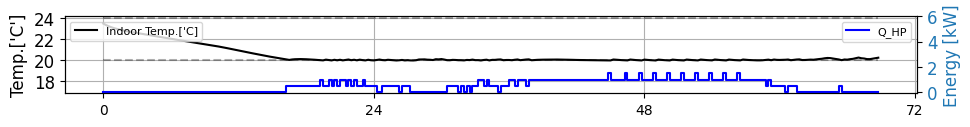

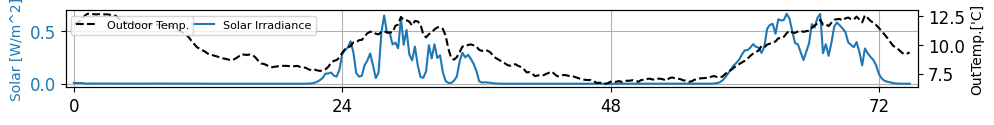

In [ ]:
import matplotlib.ticker as ticker
#Visualizing results
X = np.array(X).reshape(t_eval.size-48,nx)
U = np.array(U).reshape(t_eval.size-48,nu)
#------------------------------------------
#Saving and Loading Xs adn Us
#np.savetxt("X.csv", X, delimiter=",")
#np.savetxt("U.csv", U, delimiter=",")
#Loading
#X = np.loadtxt("X-20.csv", delimiter=",")
#U = np.loadtxt("U-20.csv", delimiter=",")
#---------------------------------------
print("Max Indoor Temp.: ",np.max((X[:,0])))
print("Min Indoor Temp.: ",np.min((X[:,0])))
print("HP Power Consumption: ",dt*np.sum(U[:,0]))
#print("DH Power Consumption: ",dt*np.sum(U[:,1]))
#PLOTING TEMP. and POWERS
#COMBINED - AWESOME B)
fig, ax5 = plt.subplots()
fig.set_size_inches(11, 1) #11,1 paper size
color = 'tab:blue'
ax5.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax5.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax5.plot(t_eval[0:-48],X[:,0],"k-",label=f"Indoor Temp.['C]")
#ax5.plot(t_eval[0:-48],,"k-",label=f"Env Temp.['C]")
ax5.legend(loc="upper left",fontsize = 8,)  #, bbox_to_anchor=(0.3,1)
ax5.plot(t_eval[0:-48],20*np.ones(t_eval[0:-48].size),"k--", alpha=.3)
ax5.plot(t_eval[0:-48],24*np.ones(t_eval[0:-48].size),"k--", alpha=.3)
ax5.set_ylabel("Temp.['C']", fontsize=12)
ax5.tick_params(axis='y',labelsize = 12,)
ax5.grid()
ax6 = ax5.twinx()
ax6.step(t_eval[0:-48],U[:,0],"b-",label="P_HP")
ax6.set_ylabel("Energy [kW]", color = color, fontsize=12)
ax6.tick_params(axis='y', labelcolor=color,labelsize = 12,)
ax6.tick_params(axis='y',labelsize = 12,)
ax6.legend(loc='upper right',ncol=2,fontsize = 8,)
y_ticks = [18,20,22,24,26]#
#x_ticks = list(range(0, 169, 24))
#ax5.set_xticks(x_ticks)
ax5.set_yticks(y_ticks)
ax5.set_ylim(16.8, 24.2)
ax6.set_yticks([0,2,4,6])
#ax5.set_ymargin(1)
#ax5.set_xlim(-1, 169)
#ax5.set_xmargin(0.01)
fig.savefig('full_figure.png',bbox_inches='tight', dpi=150)
#----------------------------------------------------------------
#PLOT SUN RADIANCE AND OUTDOOR TEMP:
#All in one
fig = plt.figure(figsize=(11,1))
ax3 = fig.add_subplot(111)
ax3.plot(t_eval[0:-24],Q_sol_seri[0:t_eval[0:-24].size],label="Solar Irradiance") #tIMES 1000 to turn it into W/m^2
ax3.legend(loc='upper right', bbox_to_anchor=(0.3,1),fontsize = 8,)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax3.grid()
ax3.set_ylabel("Solar [W/m^2]", color = color)
ax4 = ax3.twinx()
#color = 'tab:red'
ax4.plot(t_eval[0:-24],T_o_seri[0:t_eval[0:-24].size],"k--",label="Outdoor Temp.")
ax4.legend(loc='upper left',fontsize = 8,)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(24))
#ax4.grid()
ax4.set_xlabel("Time[hr]")
ax4.set_ylabel("OutTemp.['C]") #, color = b
ax4.tick_params(axis='y',labelsize = 12,)
ax3.tick_params(axis='x',labelsize = 12,)
ax3.tick_params(axis='y',labelcolor="tab:blue",labelsize = 12,)
ax3.set_xmargin(0.01)

# **2.PID CONTROLLER (for comparison)**

In [ ]:
#NOTE: Run the first 5 blocks on top of the document and then PID will work

In [14]:
#State_Equations to simulate building behaviour (using the same RC model)
def make_F(T_o = 0, Q_sol = 0,n_Ti=0,n_Te=0):
  states = casadi.SX.sym("states",nx)
  ctrls = casadi.SX.sym("ctrls",nu) #
  Ti = states[0]
  Te = states[1]
  Qh = ctrls[0]

  #state-space equations - Discrete
  #EQ: X(n+1) = A*X(n) + B*U(n) + Brownian_Motion_noise #,
  [Ti_next,Te_next] = np.dot(Ad,np.array([Ti,Te])) + np.dot(Bd,np.array([Qh*Eff_h,T_o,Q_sol])) + np.hstack((n_Ti,n_Te)) #

  states_next = casadi.vertcat(Ti_next,Te_next)
  F = casadi.Function("F",[states,ctrls],[states_next],["x","u"],["x_next"])
  return F

In [15]:
class PIDController:
    def __init__(self, Kp, Ki, Kd, deadband=1, setpoint=0.0):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.setpoint = setpoint
        self.deadband = deadband
        self.integral = 0.0
        self.prev_error = 0.0

    def compute(self, measured_value, dt):
        #t_op = (measured_value[0] + measured_value[1])/2
        Ti = measured_value[0]
        error = max(0,Ti - (self.setpoint+self.deadband)) + max(0,(self.setpoint-self.deadband) - Ti)
        self.integral += error * dt
        derivative = (error - self.prev_error) / dt if dt > 0 else 0.0
        self.prev_error = error

        control = (
            self.Kp * error +
            self.Ki * self.integral +
            self.Kd * derivative
        )
        return control

In [16]:
x_init_PID = [21,21]
#dt = 60  # time step in seconds
pid = PIDController(Kp=5.0, Ki=0.1, Kd=0.05, deadband=1.0,setpoint=22.0)
obj_PID = [0,0,0]
# Time settings
#T_total = 3600 * 6  # 6 hours
X = [x_init_PID]
U = []
x_current = x_init_PID
#t_eval
Qh = 0
for t in range(t_eval.size-2*K):
    #Ti = x_current[0]
    F = make_F(T_o=T_o_seri[t],Q_sol=Q_sol_seri[t],n_Ti=noise_Ti[t],n_Te=noise_Te[t]) #Simulates the buulding behaviour
    # PID computes Qhp based on indoor temperature
    if t%2 == 0:   #ADDITION: This if statement shows how fast "u" can be changed. Now it can take a new variable every 2*1/2 =1 h
      Qh = pid.compute(x_current, dt)
      Qh = np.clip(Qh, 0, 5)  # Clip if needed (e.g., 0–10 kW)
      Qh = np.round(Qh/0.2)*0.2
      control_input = casadi.DM([Qh])
      x_current = F(x=x_current,u=control_input)["x_next"].full().flatten() #Gets the next temp. when given u
    # Evaluate CasADi function to get next state
    X.append(x_current)
    U.append(Qh)
    # Store for analysis
    #obj_PID[0] += compute_stage_cost(x_current,control_input,t3=t,w1=1)[1] #cost ,
    #obj_PID[1] += compute_stage_cost(x_current,control_input,t3=t,w1=1)[2] #CO2 emission ,
    #obj_PID[2] += compute_stage_cost(x_current,control_input,t3=t,w1=1)[3] #comfort


Max Indoor Temp.:  21.327683581502313
Min Indoor Temp.:  20.778950449609553
HP Power Consumption:  55.2


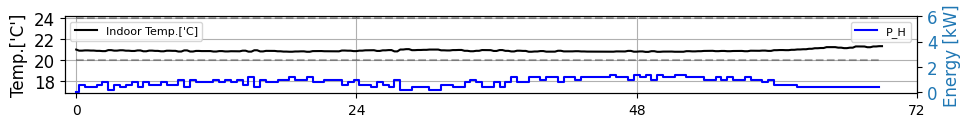

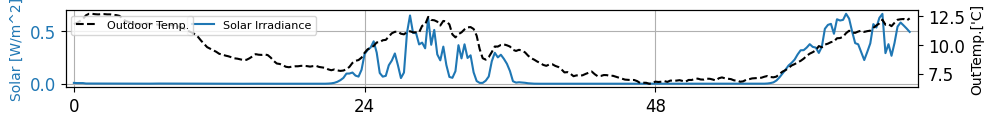

In [25]:
import matplotlib.ticker as ticker
#Visualizing results
X = np.array(X).reshape(t_eval.size-2*K+1,nx)
U = np.array(U).reshape(t_eval.size-2*K,nu)
#------------------------------------------
#Saving/Loading Xs adn Us
#np.savetxt("X.csv", X, delimiter=",")
#np.savetxt("U.csv", U, delimiter=",")
#Loading
#X = np.loadtxt("X-20.csv", delimiter=",")
#U = np.loadtxt("U-20.csv", delimiter=",")
#---------------------------------------
print("Max Indoor Temp.: ",np.max((X[:,0])))
print("Min Indoor Temp.: ",np.min((X[:,0])))
print("HP Power Consumption: ",dt*np.sum(U[:,0]))
#print("DH Power Consumption: ",dt*np.sum(U[:,1]))
#PLOTING TEMP. and POWERS
#COMBINED - AWESOME B)
fig, ax5 = plt.subplots()
fig.set_size_inches(11, 1) #11,1 paper size
color = 'tab:blue'
ax5.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax5.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax5.plot(t_eval[0:-2*K+1],X[:,0],"k-",label=f"Indoor Temp.['C]")
#ax5.plot(t_eval[0:-48],,"k-",label=f"Env Temp.['C]")
ax5.legend(loc="upper left",fontsize = 8,)  #, bbox_to_anchor=(0.3,1)
ax5.plot(t_eval[0:-2*K+1],20*np.ones(t_eval[0:-2*K+1].size),"k--", alpha=.3)
ax5.plot(t_eval[0:-2*K+1],24*np.ones(t_eval[0:-2*K+1].size),"k--", alpha=.3)
ax5.set_ylabel("Temp.['C']", fontsize=12)
ax5.tick_params(axis='y',labelsize = 12,)
ax5.grid()
ax6 = ax5.twinx()
ax6.step(t_eval[0:-2*K],U[:,0],"b-",label="P_H")
ax6.set_ylabel("Energy [kW]", color = color, fontsize=12)
ax6.tick_params(axis='y', labelcolor=color,labelsize = 12,)
ax6.tick_params(axis='y',labelsize = 12,)
ax6.legend(loc='upper right',ncol=2,fontsize = 8,)
y_ticks = [18,20,22,24,26]#
#x_ticks = list(range(0, 169, 24))
#ax5.set_xticks(x_ticks)
ax5.set_yticks(y_ticks)
ax5.set_ylim(16.8, 24.2)
ax6.set_yticks([0,2,4,6])
#ax5.set_ymargin(1)
ax5.set_xlim(-1, 72)
#ax5.set_xmargin(0.01)
fig.savefig('full_figure.png',bbox_inches='tight', dpi=150)
#----------------------------------------------------------------
#PLOT SUN RADIANCE AND OUTDOOR TEMP:
#All in one
fig = plt.figure(figsize=(11,1))
ax3 = fig.add_subplot(111)
ax3.plot(t_eval[0:-2*K+1],Q_sol_seri[0:t_eval[0:-2*K+1].size],label="Solar Irradiance") #tIMES 1000 to turn it into W/m^2
ax3.legend(loc='upper right', bbox_to_anchor=(0.3,1),fontsize = 8,)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax3.grid()
ax3.set_ylabel("Solar [W/m^2]", color = color)
ax4 = ax3.twinx()
#color = 'tab:red'
ax4.plot(t_eval[0:-2*K+1],T_o_seri[0:t_eval[0:-2*K+1].size],"k--",label="Outdoor Temp.")
ax4.legend(loc='upper left',fontsize = 8,)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(24))
#ax4.grid()
ax4.set_xlabel("Time[hr]")
ax4.set_ylabel("OutTemp.['C]") #, color = b
ax4.tick_params(axis='y',labelsize = 12,)
ax3.tick_params(axis='x',labelsize = 12,)
ax3.tick_params(axis='y',labelcolor="tab:blue",labelsize = 12,)
ax3.set_xmargin(0.01)